# Candidate figures — Introduction & Literature Review chapters

Each cell below produces **one candidate figure** for Chapter 1 (Introduction) or Chapter 2 (Literature Review).
Every plot uses either (a) data computed live from this repo's corpora/embeddings, or (b) facts hand-coded from the
venue audit of August 2026 (each such cell notes its source). Nothing is invented. Pick your selection; the last
cell maps each figure to the thesis section it fits.

**No thesis results appear in this notebook.** Computed figures use only generic baselines (k-means, Ward, GMM) to
illustrate field-level phenomena; Fig. N reports *published* numbers from the literature. CriterionClust / RQ result
figures live in the RQ analysis notebooks.

In [1]:
import json, itertools, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import normalized_mutual_info_score as nmi, silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment
warnings.filterwarnings('ignore')

REPO = Path.cwd().parents[1] if Path.cwd().name == 'source' else Path.cwd()
ROOT = REPO
RQ1 = REPO / 'data' / 'rq1'
NB = REPO / 'data' / 'benchmarks'
FIGS = Path.cwd().parent if Path.cwd().name == 'source' else Path.cwd() / 'finalplots'
PUBCSV = Path.cwd() / 'published_results.csv'

# fixed categorical palette (Paul Tol bright - colourblind-safe), assigned in fixed order, never cycled
PAL = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6, 'font.size': 10})

DISPL = {"banking77": "Banking77", "clinc150": "CLINC(I)", "clinc150_domain": "CLINC(D)", "mtop_intent": "MTOP(I)", "mtop_domain": "MTOP(D)", "massive_intent": "MASSIVE(I)", "massive_domain": "MASSIVE(D)", "20newsgroups": "20 Newsgroups", "tweet89": "Tweet89", "tweet": "Tweet", "fabsa": "FABSA", "fewrel": "FewRel", "fewnerd": "FewNerd", "fewevent": "FewEvent", "arxiv_fine": "ArXiv-S2S", "stackexchange_cl": "StackEx-S2S", "reddit_s2s": "Reddit-S2S", "arxiv": "ArXiv-P2P", "reddit": "Reddit-P2P", "stackoverflow": "StackEx-P2P", "stackoverflow20": "StackOverflow", "mcid": "M-CID", "snips": "SNIPS", "dbpedia": "DBPedia", "bbcnews": "BBC News"}

def load_bench(b):
    """Return (texts:list[str], gold:np.ndarray) for newbench or RQ1-style benchmarks."""
    f = NB/f'{b}_texts.csv'
    if f.exists():
        d = pd.read_csv(f); return d.text.astype(str).tolist(), d.gold.to_numpy()
    t = pd.read_csv(RQ1/'texts'/f'{b}.csv')['text'].fillna('').astype(str).tolist()
    g = pd.read_csv(RQ1/'partitions'/f'{b}.csv')['true_label'].to_numpy()
    return t, g

def hungarian_acc(gold, lab):
    gs = pd.factorize(pd.Series(gold))[0]; ls = pd.factorize(pd.Series(lab))[0]
    C = np.zeros((ls.max()+1, gs.max()+1), int); np.add.at(C, (ls, gs), 1)
    r, c = linear_sum_assignment(-C); return C[r, c].sum()/len(gold)
print('setup ok — repo root:', ROOT)

setup ok — repo root: /Users/louisarts/Desktop/Chattermill/LLM_clustering


## Fig. A2 — Timeline of the 11 covered algorithms only
One row per algorithm (chronological), stage-coloured chips at the publication date — one chip per intervention stage the method uses, so multi-stage methods (e.g. Few-Shot Clustering) are represented faithfully.

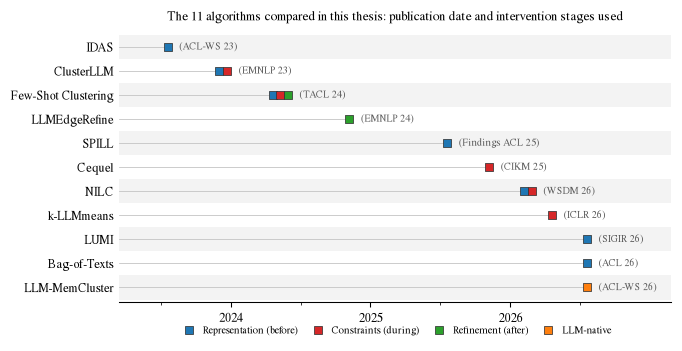

In [2]:
# One row per algorithm; stage-coloured chips at its publication date, one chip per
# intervention stage the method uses (several methods span multiple stages).
STAGES = ['Representation (before)', 'Constraints (during)', 'Refinement (after)', 'LLM-native']
SCOL = dict(zip(STAGES, ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']))
ALGOS = [   # (name, venue, year-month, stages used  — per the papers as reviewed in §2.4)
 ('IDAS', 'ACL-WS 23', 2023.55, ['Representation (before)']),
 ('ClusterLLM', 'EMNLP 23', 2023.92, ['Representation (before)', 'Constraints (during)']),
 ('Few-Shot Clustering', 'TACL 24', 2024.30, ['Representation (before)', 'Constraints (during)', 'Refinement (after)']),
 ('LLMEdgeRefine', 'EMNLP 24', 2024.85, ['Refinement (after)']),
 ('SPILL', 'Findings ACL 25', 2025.55, ['Representation (before)']),
 ('Cequel', 'CIKM 25', 2025.85, ['Constraints (during)']),
 ('NILC', 'WSDM 26', 2026.10, ['Representation (before)', 'Constraints (during)']),
 ('k-LLMmeans', 'ICLR 26', 2026.30, ['Constraints (during)']),
 ('LUMI', 'SIGIR 26', 2026.55, ['Representation (before)']),
 ('Bag-of-Texts', 'ACL 26', 2026.55, ['Representation (before)']),
 ('LLM-MemCluster', 'ACL-WS 26', 2026.55, ['LLM-native']),
]
with plt.rc_context({'font.family': 'serif', 'mathtext.fontset': 'stix',
                     'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
                     'axes.linewidth': 0.7, 'xtick.major.width': 0.7, 'xtick.minor.width': 0.5}):
    fig, ax = plt.subplots(figsize=(6.3, 3.3))
    for i, (name, venue, t, stages) in enumerate(ALGOS):
        if i % 2 == 0: ax.axhspan(i - 0.5, i + 0.5, color='0.55', alpha=0.10, zorder=0, lw=0)
        ax.plot([2023.2, t], [i, i], color='0.75', lw=0.5, zorder=1)   # leader from name to date
        for q, st in enumerate(stages):
            ax.scatter(t + 0.055*q, i, marker='s', s=32, facecolor=SCOL[st],
                       edgecolor='#333', linewidth=0.5, zorder=3)
        ax.annotate(f'({venue})', (t + 0.055*len(stages) + 0.03, i), fontsize=6.6,
                    color='0.35', va='center', ha='left')
    ax.set_yticks(range(len(ALGOS)))
    ax.set_yticklabels([a[0] for a in ALGOS], fontsize=8)
    ax.set_xlim(2023.2, 2027.15); ax.set_ylim(-0.6, len(ALGOS)-0.4); ax.invert_yaxis()
    ax.set_xticks([2024, 2025, 2026]); ax.set_xticklabels(['2024', '2025', '2026'], fontsize=8)
    ax.set_xticks([2023.5, 2024.5, 2025.5, 2026.5], minor=True)
    ax.tick_params(axis='x', which='both', direction='out', color='black')
    ax.tick_params(axis='y', length=0)
    ax.grid(False)
    for sp in ('top', 'right', 'left'): ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('black')
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([], [], marker='s', ls='', mfc=SCOL[st], mec='#333', mew=0.5,
                              ms=5.5, label=st) for st in STAGES],
              loc='upper center', bbox_to_anchor=(0.5, -0.055), ncol=4, frameon=False, fontsize=6.6,
              handletextpad=0.4, columnspacing=1.0)
    fig.savefig(FIGS / 'fig_roster_timeline.pdf', bbox_inches='tight')
    ax.set_title('The 11 algorithms compared in this thesis: publication date and intervention stages used',
                 fontsize=8.5, pad=8)   # notebook-only; thesis caption lives in LaTeX
    plt.tight_layout(); plt.show()

## Fig. C — The benchmark landscape: corpus size vs. number of gold classes
Computed live from the corpora used in this thesis (subsampled evaluation sets, as clustered in Ch. 4–6).
Colour = task family. Log–log; the striking spread in granularity (7 → 121 classes) previews the granularity problem (§2.2.3, RQ2).

skip 20newsgroups [Errno 2] No such file or directory: '/Users/louisarts/Desktop/Chattermill/LLM_clustering/data/rq1/texts/20newsgroups.csv'
skip stackoverflow [Errno 2] No such file or directory: '/Users/louisarts/Desktop/Chattermill/LLM_clustering/data/rq1/texts/stackoverflow.csv'
skip tweet [Errno 2] No such file or directory: '/Users/louisarts/Desktop/Chattermill/LLM_clustering/data/rq1/texts/tweet.csv'
skip fabsa [Errno 2] No such file or directory: '/Users/louisarts/Desktop/Chattermill/LLM_clustering/data/rq1/texts/fabsa.csv'


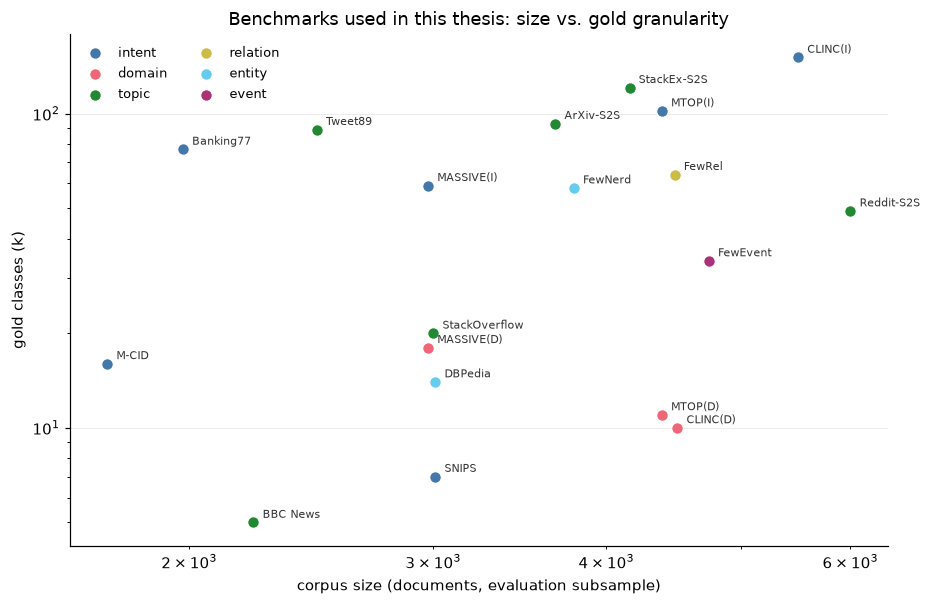

In [3]:
FAM = {'banking77': 'intent', 'clinc150': 'intent', 'massive_intent': 'intent', 'mtop_intent': 'intent',
 'clinc150_domain': 'domain', 'massive_domain': 'domain', 'mtop_domain': 'domain',
 '20newsgroups': 'topic', 'arxiv_fine': 'topic', 'reddit_s2s': 'topic', 'stackexchange_cl': 'topic',
 'stackoverflow': 'topic', 'tweet': 'topic', 'tweet89': 'topic',
 'fabsa': 'aspect-sentiment', 'fewrel': 'relation', 'fewnerd': 'entity', 'fewevent': 'event',
 'stackoverflow20': 'topic', 'bbcnews': 'topic', 'dbpedia': 'entity', 'mcid': 'intent', 'snips': 'intent'}
rows = []
for b, fam in FAM.items():
    try:
        texts, gold = load_bench(b)
        w = np.array([len(t.split()) for t in texts])
        rows.append({'bench': b, 'family': fam, 'n': len(texts), 'k': int(pd.Series(gold).nunique()),
                     'median_words': int(np.median(w)), 'docs_per_cluster': round(len(texts)/pd.Series(gold).nunique(), 1)})
    except Exception as e:
        print('skip', b, e)
B = pd.DataFrame(rows).sort_values(['family', 'bench']).reset_index(drop=True)
FAMS = ['intent', 'domain', 'topic', 'relation', 'entity', 'event', 'aspect-sentiment']
fam_col = {f: PAL[i % len(PAL)] for i, f in enumerate(FAMS)}
fig, ax = plt.subplots(figsize=(8.6, 5.6))
for f in FAMS:
    d = B[B.family == f]
    if len(d): ax.scatter(d.n, d.k, s=58, color=fam_col[f], label=f, edgecolor='white', linewidth=0.8, zorder=3)
for _, r in B.iterrows():
    ax.annotate(DISPL.get(r.bench, r.bench), (r.n, r.k), textcoords='offset points', xytext=(6, 3), fontsize=7.3, color='#333')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('corpus size (documents, evaluation subsample)'); ax.set_ylabel('gold classes (k)')
ax.legend(frameon=False, fontsize=8.5, ncol=2)
ax.set_title('Benchmarks used in this thesis: size vs. gold granularity', fontsize=11.5)
plt.tight_layout(); plt.show()

## Fig. D2 — The 19 compared benchmarks: granularity and size
One dot per benchmark, restricted to the 19 corpora with published peer-reviewed results: horizontal position is
the gold cluster count $k$ (log scale), dot area scales with the number of documents (dots are semi-transparent and
may overlap), the number inside is the corpus size in thousands of documents, and colour marks the criterion family.

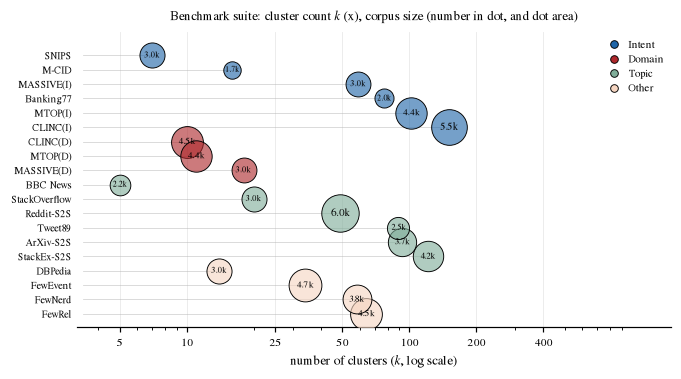

In [4]:
import matplotlib.colors as mcolors
GROUP = {'intent': 'Intent', 'domain': 'Domain', 'topic': 'Topic',
         'relation': 'Other', 'entity': 'Other', 'event': 'Other', 'aspect-sentiment': 'Other'}
GORDER = ['Intent', 'Domain', 'Topic', 'Other']
GCOL = {'Intent': '#2066a8', 'Domain': '#ae282c', 'Topic': '#80ae9a', 'Other': '#f6d6c2'}
YEAR = {'20newsgroups': 1995, 'bbcnews': 2006, 'dbpedia': 2015, 'tweet': 2016, 'tweet89': 2016,
        'stackoverflow20': 2017, 'fewrel': 2018, 'snips': 2018, 'clinc150': 2019, 'clinc150_domain': 2019,
        'banking77': 2020, 'fewevent': 2020, 'mcid': 2020, 'fewnerd': 2021, 'mtop_intent': 2021,
        'mtop_domain': 2021, 'arxiv_fine': 2023, 'fabsa': 2023, 'massive_intent': 2023,
        'massive_domain': 2023, 'reddit_s2s': 2023, 'stackexchange_cl': 2023, 'stackoverflow': 2023}
LIT19 = {'banking77','clinc150','clinc150_domain','mtop_intent','mtop_domain','massive_intent','massive_domain',
         'tweet89','stackoverflow20','mcid','snips','dbpedia','reddit_s2s','arxiv_fine','stackexchange_cl',
         'fewrel','fewnerd','fewevent','bbcnews'}          # the 19 with published comparisons
Bb = B[B.bench.isin(LIT19)].copy(); assert len(Bb) == 19, len(Bb)
Bb['group'] = Bb.family.map(GROUP)
Bb['disp'] = Bb.bench.map(lambda b: DISPL.get(b, b)); Bb['year'] = Bb.bench.map(YEAR)
Bb = Bb.sort_values(['group', 'k'], key=lambda c: c.map({g: i for i, g in enumerate(GORDER)}) if c.name == 'group' else c)
Bb = Bb.iloc[::-1].reset_index(drop=True)
nmin, nmax = Bb.n.min(), Bb.n.max()
size = lambda n: 130 + 470*(n - nmin)/(nmax - nmin)          # big dots; overlap is intentional
with plt.rc_context({'font.family': 'serif', 'mathtext.fontset': 'stix',
                     'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
                     'axes.linewidth': 0.8}):
    fig, ax = plt.subplots(figsize=(6.3, 3.55))               # A4 text width, wide-and-thin
    for i, r in Bb.iterrows():
        ax.plot([3.4, r.k], [i, i], color='0.82', lw=0.5, zorder=1)
    for i, r in Bb.iterrows():                                 # large dots first, small on top
        ax.scatter(r.k, i, s=size(r.n), facecolor=mcolors.to_rgba(GCOL[r.group], 0.62),
                   edgecolor='black', linewidth=0.6, zorder=3 + (nmax - r.n)/nmax)
    for i, r in Bb.iterrows():
        ax.text(r.k, i, f'{r.n/1000:.1f}k', ha='center', va='center', zorder=6, color='black',
                fontsize=4.8 + 1.9*(r.n - nmin)/(nmax - nmin))
    ax.set_yticks(range(len(Bb))); ax.set_yticklabels(Bb.disp, fontsize=6.6)
    ax.set_xscale('log'); ax.set_xlabel('number of clusters ($k$, log scale)', fontsize=8.5, labelpad=4)
    ax.set_xlim(3.2, 1500); ax.set_ylim(-0.9, len(Bb)+0.6)
    ax.set_xticks([5, 10, 25, 50, 100, 200, 400])
    ax.set_xticklabels(['5', '10', '25', '50', '100', '200', '400'])
    ax.tick_params(axis='x', labelsize=7.5); ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=0.25, linewidth=0.6); ax.grid(axis='y', alpha=0)
    for sp in ('top', 'right', 'left'): ax.spines[sp].set_visible(False)
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([], [], marker='o', ls='', mfc=GCOL[g], mec='black', mew=0.6,
                              ms=5, label=g) for g in GORDER],
              loc='upper right', frameon=False, fontsize=7, handletextpad=0.4,
              labelspacing=0.35, borderpad=0.2)
    fig.savefig(FIGS/'fig_benchmark_bubbles.pdf', bbox_inches='tight')
    ax.set_title('Benchmark suite: cluster count $k$ (x), corpus size (number in dot, and dot area)',
                 fontsize=8.5, pad=8)
    plt.tight_layout(); plt.show()

## Fig. R — Method × benchmark ACC matrix
One row per variant, matching the 14-row roster table; cell = the paper's
published ACC, white = not evaluated. The empty area **is** the finding of
§2.5.2: coverage is fragmented, and no two methods share a full suite. Values are verbatim from the papers and
were obtained under different encoders/protocols, so compare within rows, not across them.

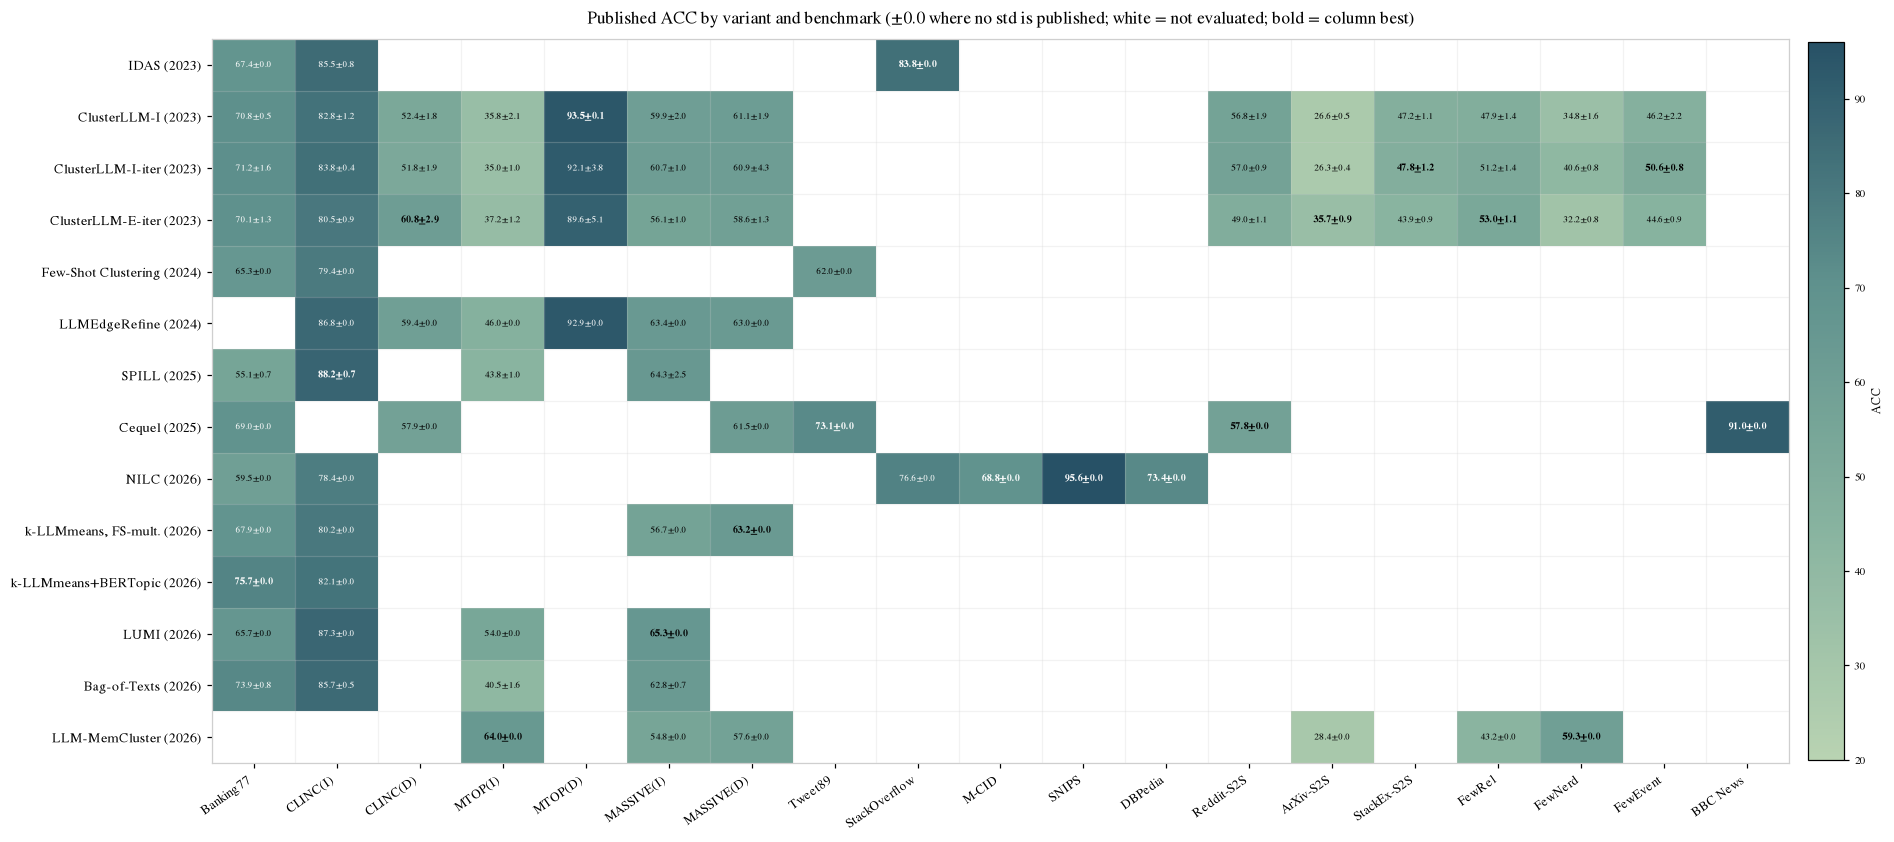

In [5]:
import matplotlib.colors as mcolors
PUB = pd.read_csv(PUBCSV)   # canonical store of published numbers (edit there)
BENCHES = ['Banking77', 'CLINC(I)', 'CLINC(D)', 'MTOP(I)', 'MTOP(D)', 'MASSIVE(I)', 'MASSIVE(D)', 'Tweet89',
           'StackOverflow', 'M-CID', 'SNIPS', 'DBPedia', 'Reddit-S2S', 'ArXiv-S2S', 'StackEx-S2S',
           'FewRel', 'FewNerd', 'FewEvent', 'BBC News']
ROW_ORDER = ['IDAS (2023)', 'ClusterLLM-I (2023)', 'ClusterLLM-I-iter (2023)', 'ClusterLLM-E-iter (2023)',
             'Few-Shot Clustering (2024)', 'LLMEdgeRefine (2024)', 'SPILL (2025)', 'Cequel (2025)', 'NILC (2026)', 'k-LLMmeans, FS-mult. (2026)', 'k-LLMmeans+BERTopic (2026)',
             'LUMI (2026)', 'Bag-of-Texts (2026)', 'LLM-MemCluster (2026)']
def draw_matrix(metric, ramp, vmin, vmax, all_rows=True, fname=None):
    d = PUB[PUB.metric == metric]
    rows = ROW_ORDER if all_rows else [r for r in ROW_ORDER if r in set(d.display_row)]
    V = np.full((len(rows), len(BENCHES)), np.nan); S = np.full_like(V, np.nan)
    for _, r in d.iterrows():
        if r.display_row in rows and r.benchmark in BENCHES:
            i, j = rows.index(r.display_row), BENCHES.index(r.benchmark)
            V[i, j] = r.value; S[i, j] = r['std'] if pd.notna(r['std']) else np.nan
    cmap = mcolors.LinearSegmentedColormap.from_list('ramp', ramp); cmap.set_bad('white')
    plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'stix',
                         'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif']})
    fig, ax = plt.subplots(figsize=(0.78*len(BENCHES)+2.5, 0.44*len(rows)+1.6)); ax.grid(False)
    im = ax.imshow(np.ma.masked_invalid(V), cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto', alpha=0.95)
    cb = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.022, pad=0.012)
    cb.ax.tick_params(labelsize=7)
    cb.set_label(metric, fontsize=8)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            if not np.isnan(V[i, j]):
                best = V[i, j] == np.nanmax(V[:, j])
                sd = 0.0 if np.isnan(S[i, j]) else S[i, j]     # unreported std displayed as ±0.0 per convention below
                frac = (V[i, j] - vmin) / (vmax - vmin)
                ax.text(j, i, f'{V[i, j]:.1f}±{sd:.1f}', ha='center', va='center', fontsize=6.2,
                        color='white' if frac > 0.62 else 'black',
                        fontweight='bold' if best else 'normal')
    ax.set_xticks(range(len(BENCHES))); ax.set_xticklabels(BENCHES, rotation=35, ha='right', fontsize=8.6)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=9)
    ax.set_xticks(np.arange(-0.5, len(BENCHES)), minor=True); ax.set_yticks(np.arange(-0.5, len(rows)), minor=True)
    ax.grid(which='minor', color='#CFCFCF', linewidth=0.8); ax.tick_params(which='minor', length=0)
    for sp in ax.spines.values(): sp.set_visible(True); sp.set_color('#CFCFCF')
    if fname:   # title-free vector export for the thesis; caption lives in LaTeX
        fig.savefig(FIGS / fname, bbox_inches='tight')
    ax.set_title(f'Published {metric} by variant and benchmark (±0.0 where no std is published; '
                 f'white = not evaluated; bold = column best)', fontsize=11.5, pad=10)
    plt.tight_layout(); plt.show()
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6, 'font.size': 10})

draw_matrix('ACC', ['#b5d1ae', '#80ae9a', '#568b87', '#1b485e'], 20, 96, fname='fig_matrix_acc.pdf')

## Fig. S — Same matrix, for NMI
Identical layout and sources; NMI values sit higher and flatter than ACC (§2.3.2).

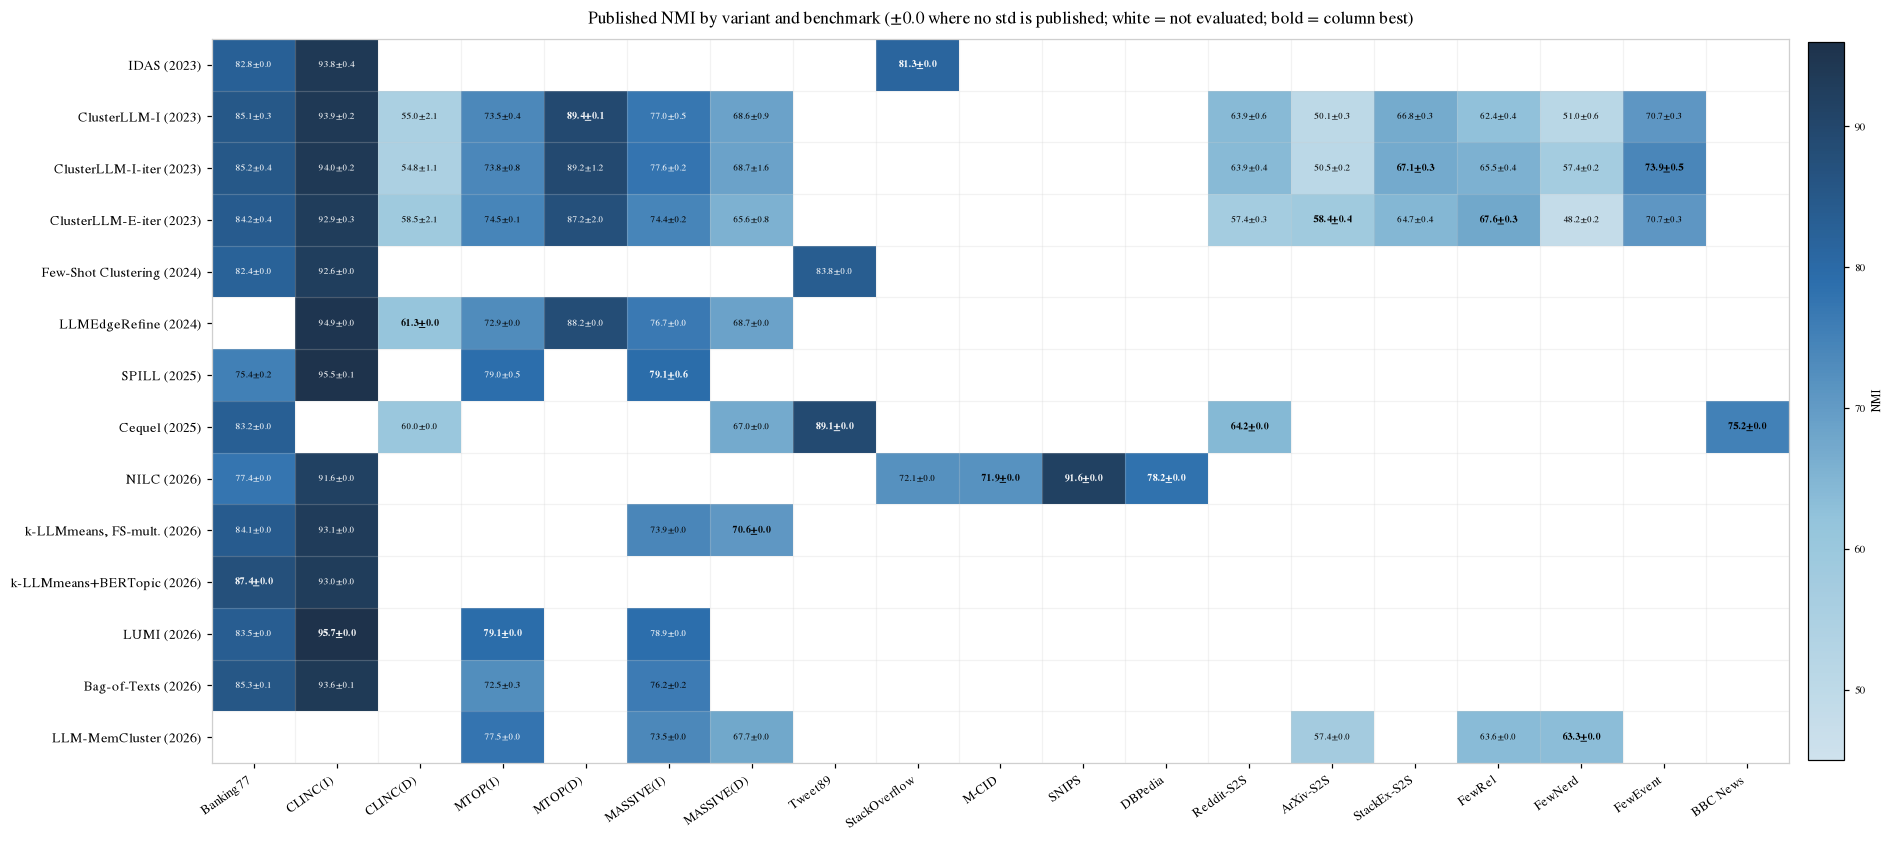

In [6]:
draw_matrix('NMI', ['#cde1ec', '#8ec1da', '#2066a8', '#122740'], 45, 96, fname='fig_matrix_nmi.pdf')

## Fig. Q — Peer-reviewed SOTA per benchmark (all benchmarks, ascending)
For every benchmark with at least one published peer-reviewed result (i.e., every column of the matrices above):
the best published NMI (left, green) and ACC (right, blue) as horizontal bars in alphabetical order, error bars
where the holding paper reports a std, and the exact holding variant named inside each bar. Derived directly from thesis/published_results.csv, so values and holders cannot drift apart.
Comparability caveat (§2.5.2) applies: different encoders and protocols per paper.

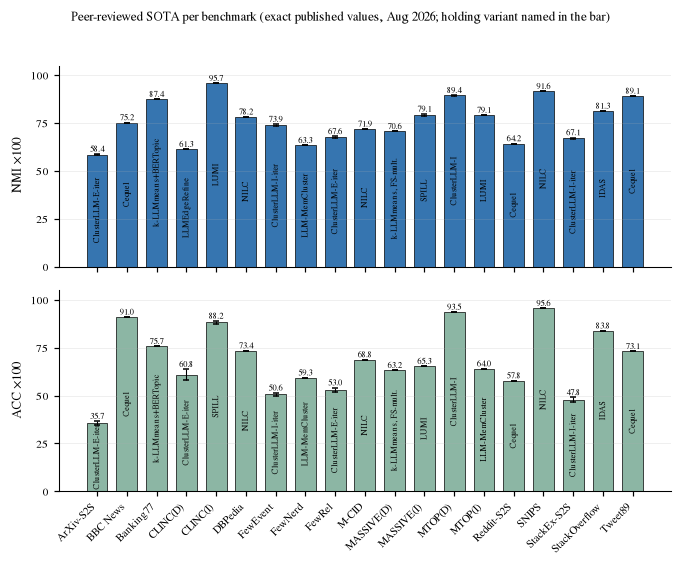

In [7]:
# Paper-standard layout: vertical bars, benchmarks on x, stacked metric panels, print size.
with plt.rc_context({'font.family': 'serif', 'mathtext.fontset': 'stix',
                     'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
                     'axes.linewidth': 0.7}):
    fig, axes = plt.subplots(2, 1, figsize=(6.3, 5.2), sharex=True)
    order_b = sorted(PUB.benchmark.unique())
    for ax, metric, col in [(axes[0], 'NMI', '#2066a8'), (axes[1], 'ACC', '#80ae9a')]:
        d = PUB[PUB.metric == metric]
        best = d.loc[d.groupby('benchmark').value.idxmax()].set_index('benchmark').loc[order_b]
        x = np.arange(len(best))
        yerr = [0 if pd.isna(v) else v for v in best['std']]
        ax.bar(x, best.value, 0.7, color=col, alpha=0.9, edgecolor='black', linewidth=0.5,
               yerr=yerr, capsize=1.8, error_kw={'ecolor': 'black', 'elinewidth': 0.7})
        for xx, (_, r) in zip(x, best.iterrows()):
            off = 1.2 + (0 if pd.isna(r['std']) else r['std'])
            ax.text(xx, r.value + off, f'{r.value:.1f}', ha='center', fontsize=5.6, color='black')
            ax.text(xx, r.value/2, r.display_row.rsplit(' (', 1)[0], ha='center', va='center',
                    rotation=90, fontsize=5.4,
                    color='black')
        ax.set_ylabel(metric + ' ×100', fontsize=8.5)
        ax.set_ylim(0, 105); ax.set_yticks([0, 25, 50, 75, 100])
        ax.tick_params(labelsize=7.5)
        ax.grid(axis='y', alpha=0.25, linewidth=0.5); ax.grid(axis='x', alpha=0)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
    axes[1].set_xticks(np.arange(len(order_b)))
    axes[1].set_xticklabels(order_b, rotation=45, ha='right', fontsize=7)
    fig.align_ylabels(axes)
    fig.savefig(FIGS / 'fig_sota_per_benchmark.pdf', bbox_inches='tight')
    fig.suptitle('Peer-reviewed SOTA per benchmark (exact published values, Aug 2026; '
                 'holding variant named in the bar)', fontsize=8.5, y=0.98)  # notebook-only
    plt.tight_layout(rect=(0, 0, 1, 0.965)); plt.show()